<a href="https://colab.research.google.com/github/GabrielMtzSoltero/MIEC/blob/main/MIEC_clasificadorMulticlase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib .pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn import datasets ,metrics
from sklearn.model_selection import train_test_split

In [ ]:
digits = datasets.load_digits()

In [ ]:
"""
target trae la etiqueta del numero y en images trae el arreglo que contiene la
imagen del numero de 8x8 pixeles
"""
target= digits.target
images =digits.images
class_names =digits.target_names

Text(0.5, 1.0, 'Target: 1')

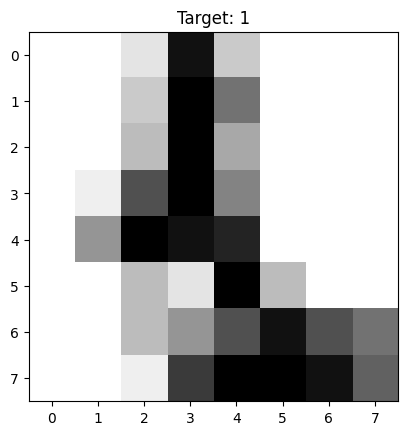

In [ ]:
#elegir un numero aleatorio dentro del numero de muestras
sample = np.random.randint(target.shape [0])
#lo mostramos (nomas para que vean como se ve)
plt.imshow(images[sample],cmap=plt.get_cmap("Greys"))
plt.title('Target: %i' % target[sample ])

In [ ]:
"""
Aplanamos los ejemplos para cambiar de tener 1797 ejemplos de 8x8 a 1797
ejemplos de 64 elementos
"""
x = images.reshape(( target.shape[0],-1))
#dividir el data set en entrenamiento y test
xtrain , xtest , ytrain , ytest = train_test_split (x, target)
#creamos el modelo de un Perceptron multicapa
model= MLPClassifier(alpha =1, max_iter =1000)
#a entrenar
model.fit(xtrain , ytrain)


MLPClassifier(alpha=1, max_iter=1000)

Train: 1.0
Test: 0.9844444444444445
Classification report: 
               precision    recall  f1-score   support

           0       1.00      0.98      0.99        42
           1       0.98      1.00      0.99        53
           2       0.97      1.00      0.99        38
           3       0.97      1.00      0.99        39
           4       0.96      1.00      0.98        55
           5       1.00      0.94      0.97        48
           6       0.98      1.00      0.99        44
           7       1.00      0.98      0.99        42
           8       0.97      0.97      0.97        40
           9       1.00      0.98      0.99        49

    accuracy                           0.98       450
   macro avg       0.98      0.98      0.98       450
weighted avg       0.98      0.98      0.98       450



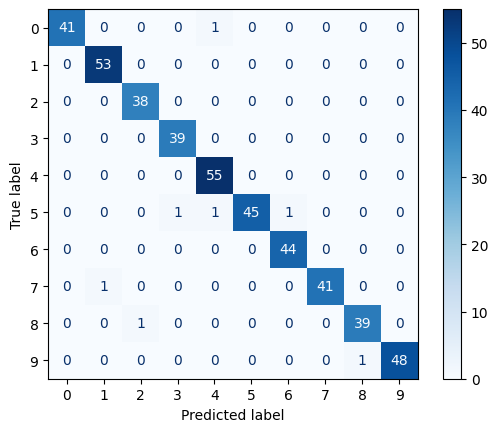

In [ ]:
# Aplicar metrica al modelo
print('Train:', model.score(xtrain , ytrain ))
print('Test:', model.score(xtest , ytest ))
#sacar la prediccion en la parte del test
ytestpred = model.predict(xtest)
cm = metrics.confusion_matrix(ytest, ytestpred)

#sacar el reporte de clasificacion
print('Classification report: \n', metrics.classification_report (ytest , ytestpred ))
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.show ()